# Food Delivery Platform Recommendation System — EDA


##Requirements
- Identify popular cuisines by **time** *(Weekday vs Weekend)*
- Analyze **repeat order patterns**
- Understand factors influencing **low ratings**
- Segment users based on **food preferences and spending**
- Provide **Outcome** mapping EDA → recommendations

> ** note:** This dataset does not include 'location', 'order_time' (hour), 'cancellation', or 'refund' data columns.  
So location-aware and cancellation/refund analyses are not possible. instead, we are working with days, and low rating analysis.


##reading and understanding the dataset :




## Task — Load the dataset

Load the CSV into a DataFrame and preview a few rows to understand what fields we have.

**Why this matters (EDA objective):**
- Foundation for all EDA; confirms dataset is loaded correctly.


In [72]:
import pandas as pd

df = pd.read_csv("foodhub_order.csv")
df.head()



,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


## Task — Basic dataset inspection

**What we are doing:** Check dataset size, data types, missing values, and summary statistics.

**Why this matters (EDA objective):**
- Understand columns and types before plotting/aggregation.


In [73]:
df.shape
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [126]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time,late_delivery
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749,0.078504
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637,0.269033
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000,0.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000,0.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000,0.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000,0.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000,1.000000


checking for null values

In [5]:
df.isnull().sum()


,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


checking for duplicates

In [74]:
df.duplicated().sum()


np.int64(0)

## Task — Frequency analysis (popularity)

**What we are doing:** Count how often categories (like cuisine/restaurant) appear to identify what is most popular.

**Why this matters (EDA objective):**
- Supports 'popular cuisines' and baseline recommendation signals.


In [7]:
df['cuisine_type'].value_counts()


,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


<Axes: xlabel='cuisine_type'>

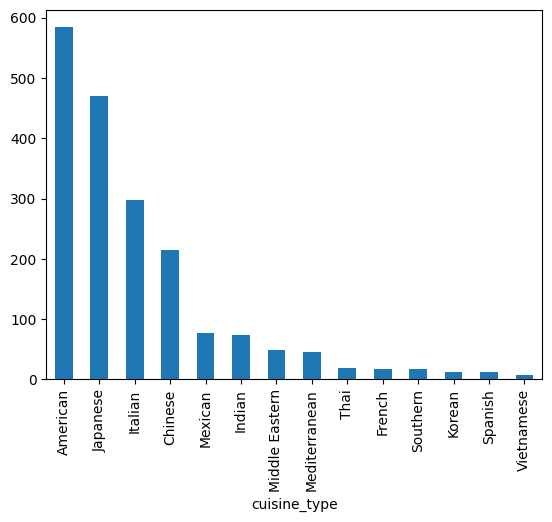

In [8]:
df['cuisine_type'].value_counts().plot(kind='bar')


## Task — Outlier and distribution checks

**What we are doing:** Use boxplots to view distribution, median, spread, and outliers (e.g., delivery delays).

**Why this matters (EDA objective):**
- Supports outlier analysis and highlights extreme cases.


<Axes: >

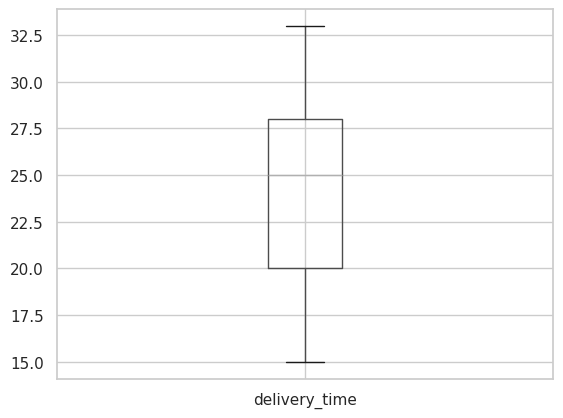

In [75]:
df.boxplot(column='delivery_time')


<Axes: >

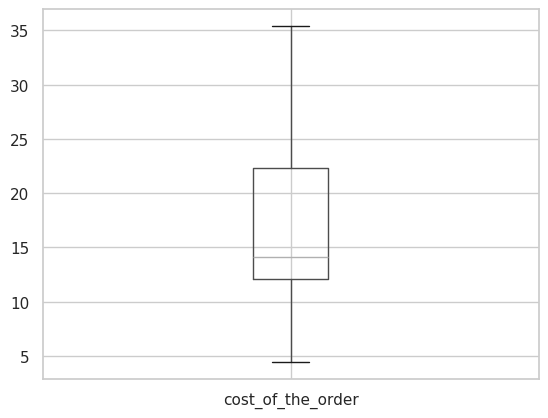

In [76]:
df.boxplot(column='cost_of_the_order')


#avg delivery time for orders grouped by rating :

In [77]:
df.groupby('rating')['delivery_time'].mean()


,delivery_time
rating,
3,24.558511
4,23.867876
5,24.212585
Not given,24.173913


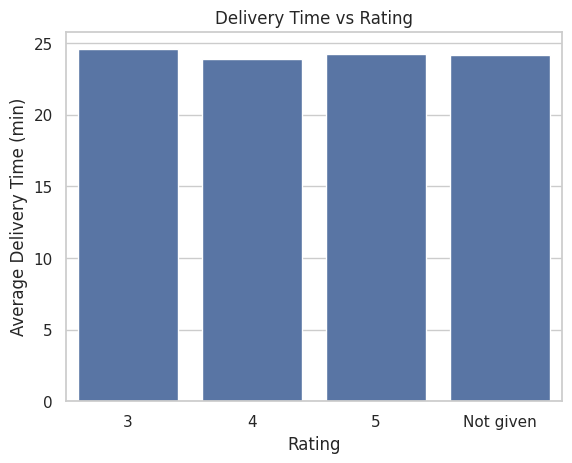

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
delivery_time_vs_rating = df.groupby('rating')['delivery_time'].mean()

# Plotting
sns.barplot(x=delivery_time_vs_rating.index, y=delivery_time_vs_rating.values)
plt.ylabel("Average Delivery Time (min)")
plt.xlabel("Rating")
plt.title("Delivery Time vs Rating")
plt.show()


#no. of orders categorised for each rating :

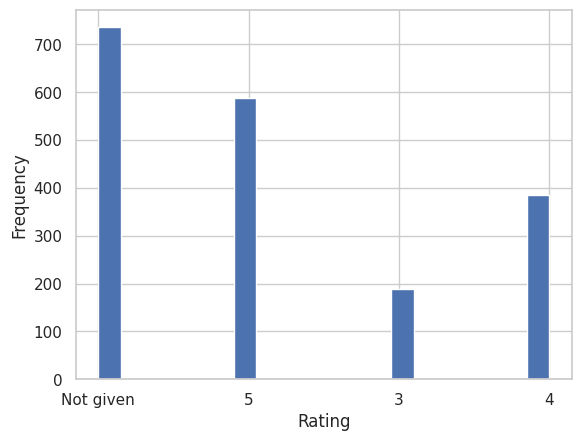

In [79]:
import matplotlib.pyplot as plt

df['rating'].hist(bins=20)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


## Task — Clean the `rating` column
Convert ratings to numeric and treat non-numeric values like 'Not given' as missing (NaN).


In [80]:
# Replace non-numeric values with NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')


In [81]:
# Check number of NaNs in each column
print(df.isna().sum())


order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64


In [82]:
# Fraction of missing values
print(df.isna().mean() * 100)  # gives % missing per column


order_id                  0.000000
customer_id               0.000000
restaurant_name           0.000000
cuisine_type              0.000000
cost_of_the_order         0.000000
day_of_the_week           0.000000
rating                   38.777661
food_preparation_time     0.000000
delivery_time             0.000000
dtype: float64


droping 38% of ratings data is too much to loose, so we convert them

In [16]:
# For a column like 'rating'
non_numeric = df[~df['rating'].apply(lambda x: str(x).replace('.','').isdigit())]
print(non_numeric)


      order_id  customer_id             restaurant_name cuisine_type  \
0      1477147       337525                     Hangawi       Korean   
1      1477685       358141   Blue Ribbon Sushi Izakaya     Japanese   
6      1477894       157711           The Meatball Shop      Italian   
10     1477895       143926  Big Wong Restaurant _¤¾Ñ¼      Chinese   
14     1478198        62667      Lucky's Famous Burgers     American   
...        ...          ...                         ...          ...   
1887   1476873       237616                 Shake Shack     American   
1891   1476981       138586                 Shake Shack     American   
1892   1477473        97838                 Han Dynasty      Chinese   
1895   1477819        35309           Blue Ribbon Sushi     Japanese   
1897   1478056       120353           Blue Ribbon Sushi     Japanese   

      cost_of_the_order day_of_the_week  rating  food_preparation_time  \
0                 30.75         Weekend     NaN              

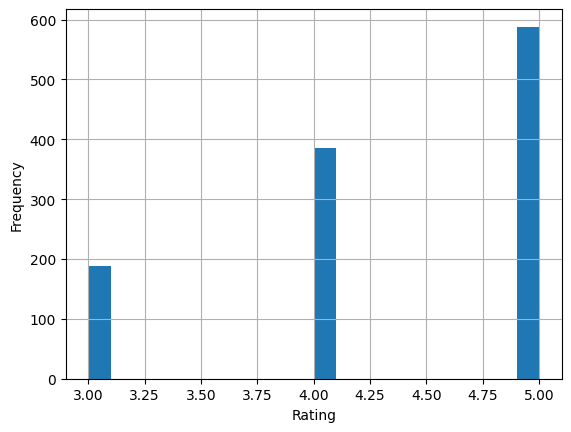

In [17]:
import matplotlib.pyplot as plt

df['rating'].hist(bins=20)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


In [18]:
skewness = df['rating'].skew()
print("Skewness:", skewness)


Skewness: -0.6488782955440754


 as there is skewness, we use median value to replace Nan ratings

In [83]:
df['rating'] = df['rating'].fillna(df['rating'].median())


In [84]:
df['rating'].isna().sum()

np.int64(0)

In [85]:
print(df.isna().sum())

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


## Task - Frequency analysis (day based)




In [86]:
# Count how many orders fall on each day of the week
df['day_of_the_week'].value_counts()


,count
day_of_the_week,
Weekend,1351
Weekday,547


## no.of restaurants :



In [87]:
df['restaurant_name'].nunique()

178

In [89]:
# Outlier and distribution checks :
# import seaborn as sns
# sns.boxplot(df['delivery_time'])
# sns.boxplot(df['cost_of_the_order'])


## avg.delivery time for each rating group, after converting Nan ratings :




In [26]:
df.groupby('rating')['delivery_time'].mean()


,delivery_time
rating,
3.0,24.558511
4.0,23.867876
5.0,24.191088


#avg cost of orders grouped by ratings :

In [90]:
df.groupby('rating')['cost_of_the_order'].mean()


,cost_of_the_order
rating,
3.0,16.223351
4.0,16.710337
5.0,16.476314


## Frequency analysis -  how many orders, each user places :


In [91]:
df['customer_id'].value_counts()


,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


##renaming the clmns :

In [92]:
df.rename(columns={
    'cost_of_the_order': 'cost',
    'food_preparation_time': 'prep_time',
    'day_of_the_week': 'day',
    'restaurant_name': 'restaurant'
}, inplace=True)


In [93]:
# Count missing values per column
print(df.isnull().sum())

# Percentage of missing values
print((df.isnull().sum() / len(df)) * 100)



order_id         0
customer_id      0
restaurant       0
cuisine_type     0
cost             0
day              0
rating           0
prep_time        0
delivery_time    0
dtype: int64
order_id         0.0
customer_id      0.0
restaurant       0.0
cuisine_type     0.0
cost             0.0
day              0.0
rating           0.0
prep_time        0.0
delivery_time    0.0
dtype: float64


In [94]:
## we can see that there are no more unknown/ Nan values

In [33]:
#####1

## EDA OBJ 1 : — Popular cuisines by time (Weekday vs Weekend)


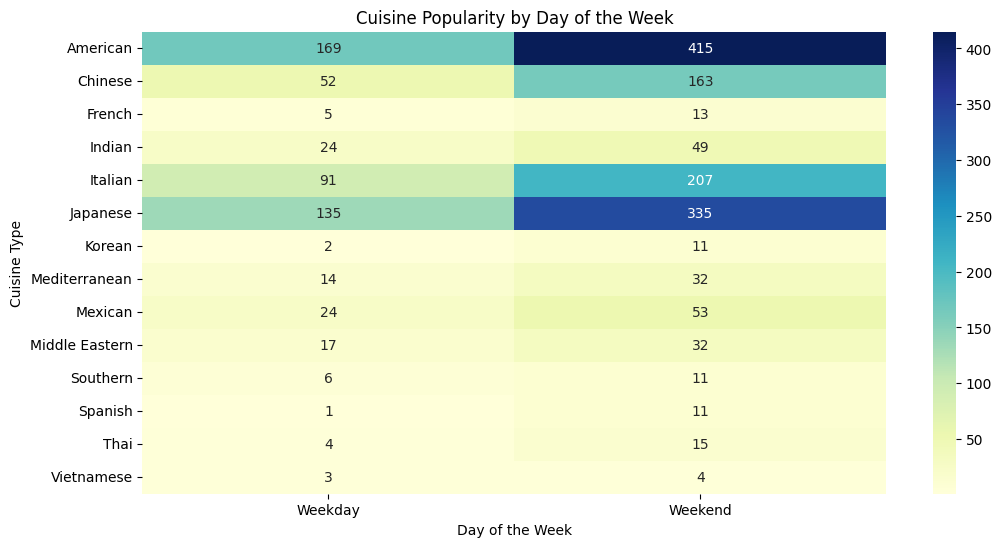

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cuisine_day = df.groupby(['cuisine_type', 'day']).size().unstack(fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(cuisine_day, cmap='YlGnBu', annot=True, fmt='d')
plt.title("Cuisine Popularity by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Cuisine Type")
plt.show()

#we can see there are more orders for each cuisine on weekends, and significantly more for those popular cuisines.

In [97]:
####2


##**EDA OBJ 2:- Repeat order patterns **




In [99]:
customer_orders = df.groupby('customer_id')['order_id'].count()

# customer_orders = df.groupby['customer_id'].count()


# How many customers are repeat customers?
repeat_customers = customer_orders[customer_orders > 1]

repeat_customers.count(), customer_orders.count()


(np.int64(416), np.int64(1200))

## no of orders placed vs no.of customers placed :


In [37]:
customer_orders.value_counts().head(100)



,count
order_id,
1,784
2,267
3,83
4,33
5,19
6,6
7,4
13,1
10,1


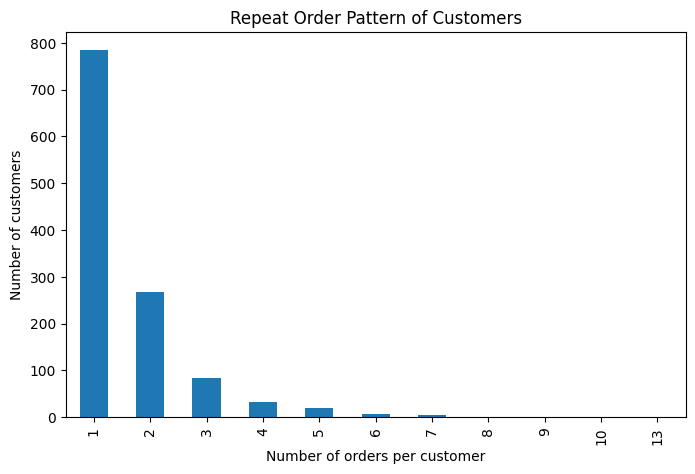

In [41]:
order_dist = customer_orders.value_counts().sort_index()

plt.figure(figsize=(8,5))
order_dist.plot(kind='bar')
plt.xlabel("Number of orders per customer")
plt.ylabel("Number of customers")
plt.title("Repeat Order Pattern of Customers")
plt.show()


In [100]:
#3

## EDA OBJ 3:-  Understand factors influencing low ratings or cancellations


#since we dont have cancellation data, we will look at low rating factors

In [101]:
low_ratings = df[df['rating'] <= 3]


In [102]:
low_ratings

,order_id,customer_id,restaurant,cuisine_type,cost,day,rating,prep_time,delivery_time
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3.0,20,24
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30
13,1477449,104548,Pylos,Mediterranean,11.30,Weekend,3.0,24,23
54,1477760,130507,Jack's Wife Freda,Mediterranean,22.75,Weekend,3.0,35,29
...,...,...,...,...,...,...,...,...,...
1860,1477330,198802,DuMont Burger,American,24.25,Weekend,3.0,28,20
1865,1476661,42755,Blue Ribbon Sushi,Japanese,12.13,Weekend,3.0,24,23
1876,1478320,85091,The Meatball Shop,Italian,13.53,Weekday,3.0,20,31
1884,1477437,304993,Shake Shack,American,31.43,Weekend,3.0,31,24


there are 188 orders which are less than 4 rating.

#lets look at factors effecting ratings, like delivery time, prep time and cuisine type.

In [103]:
df.groupby('rating')['delivery_time'].mean()


,delivery_time
rating,
3.0,24.558511
4.0,23.867876
5.0,24.191088


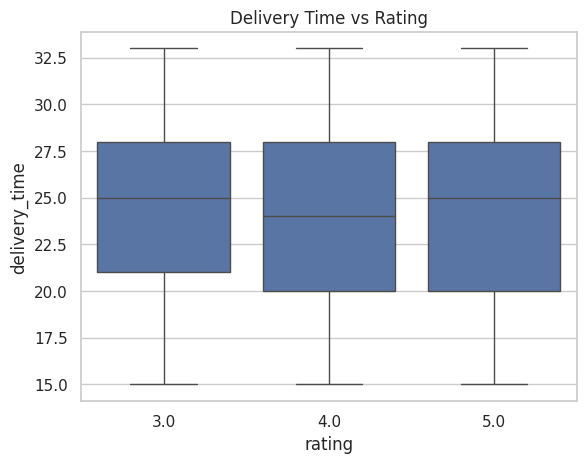

In [104]:
sns.boxplot(x='rating', y='delivery_time', data=df)
plt.title("Delivery Time vs Rating")
plt.show()


In [105]:
df.groupby('rating')['prep_time'].mean()


,prep_time
rating,
3.0,27.430851
4.0,27.396373
5.0,27.356495


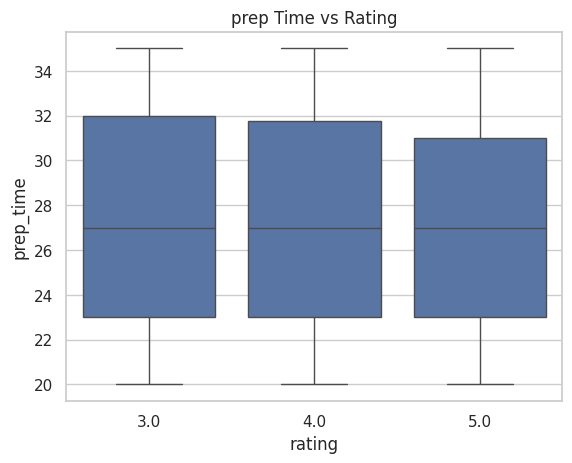

In [106]:
sns.boxplot(x='rating', y='prep_time', data=df)
plt.title("prep Time vs Rating")
plt.show()


## Task 10 — Relationship analysis (experience vs rating)

**What we are doing:** Study relationships between variables and how rating varies (e.g., delivery vs prep, colored by rating).

**Why this matters (EDA objective):**
- Supports 'factors influencing low ratings'.


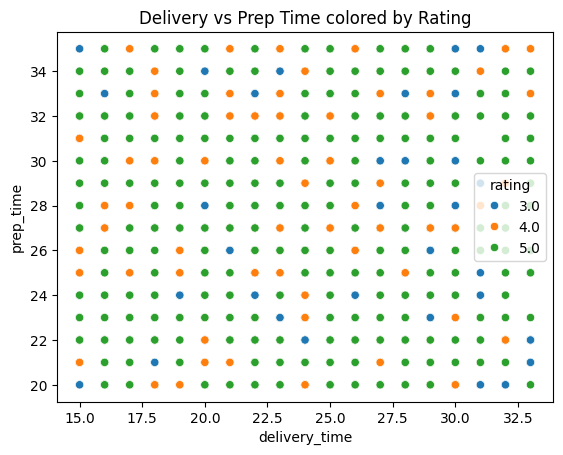

In [48]:
sns.scatterplot(
    data=df,
    x='delivery_time',
    y='prep_time',
    hue='rating',
    palette='tab10'
)
plt.title('Delivery vs Prep Time colored by Rating')
plt.show()


the ratings look like they are not effected by total time alone, so we have to look at cuisine wise to see, which cuisine restaurants make more customer-favourite food or authentic.





#ratings effected by time grouped by cuisines

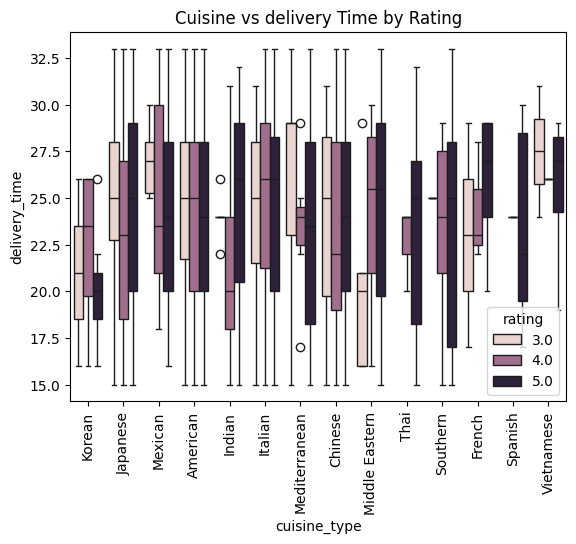

In [43]:
sns.boxplot(
    data=df,
    x='cuisine_type',
    y='delivery_time',
    hue='rating'
)
plt.xticks(rotation=90)
plt.title('Cuisine vs delivery Time by Rating')
plt.show()


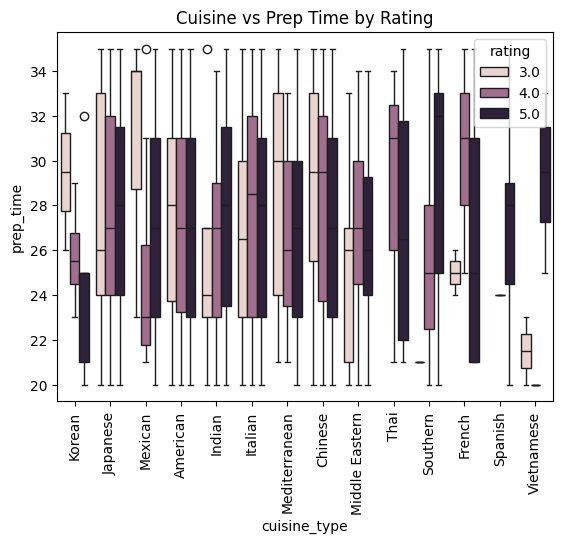

In [44]:
sns.boxplot(
    data=df,
    x='cuisine_type',
    y='prep_time',
    hue='rating'
)
plt.xticks(rotation=90)
plt.title('Cuisine vs Prep Time by Rating')
plt.show()


#ratings effected by total time for each cuisine :

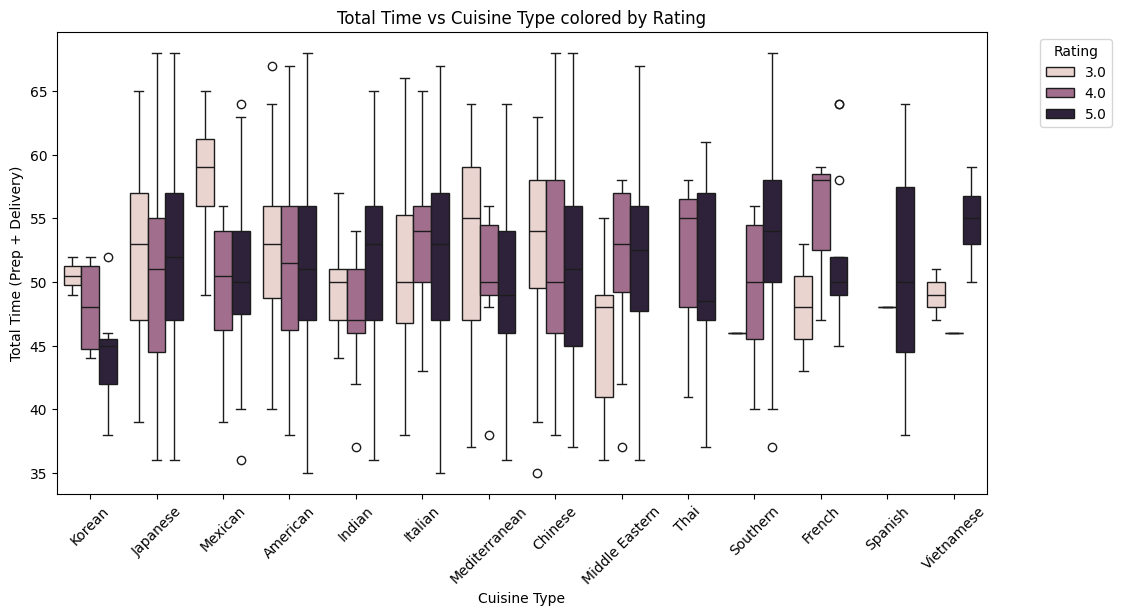

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# create a new column for total time
df['total_time'] = df['prep_time'] + df['delivery_time']

plt.figure(figsize=(12,6))
sns.boxplot(x='cuisine_type', y='total_time', data=df, hue='rating')
plt.xticks(rotation=45)
plt.ylabel('Total Time (Prep + Delivery)')
plt.xlabel('Cuisine Type')
plt.title('Total Time vs Cuisine Type colored by Rating')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


#we can see ratings for cuisines like korean, chinese, american are based on total time. where as in cuisines like indian, italian, middle eastern, customers dont mind high total time, as they understand their food might take longer prep time.

#ratings <4 based on day

In [47]:
df['low_rating'] = df['rating'] <= 3

df.groupby('day')['low_rating'].mean() * 100
#shows the percentage of high ratings based on the day.

,low_rating
day,
Weekday,11.517367
Weekend,9.252406


there are less low ratings on orders placed on weekends, comparatively.

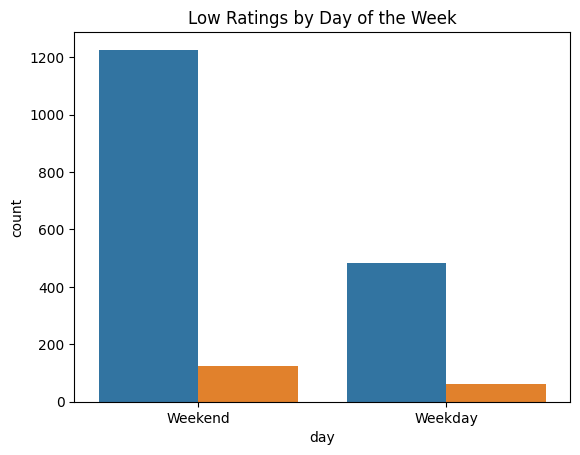

In [48]:
df['low_rating'] = df['rating'] <= 3

ax = sns.countplot(x='day', hue='low_rating', data=df)
ax.legend_.remove()

plt.title("Low Ratings by Day of the Week")
plt.show()


In [53]:
#####4

##EDA OBJ 4 :- Segment users based on food preferences and spending behavior

understanding user spending behaviour:

In [51]:
customer_seg = df.groupby('customer_id').agg({
    'order_id': 'count',
    'cost': 'mean',
    'rating': 'mean',

}).rename(columns={
    'order_id': 'order_count',
    'cost': 'avg_spend',
    'rating': 'avg_rating'
})


In [56]:
customer_seg

,order_count,avg_spend,avg_rating
customer_id,,,
1311,1,16.100,5.0
5139,1,22.260,5.0
5444,1,20.180,3.0
5693,1,8.300,5.0
6987,2,21.005,4.5
...,...,...,...
402215,1,21.290,4.0
403019,1,15.470,5.0
403833,1,6.690,5.0


#separating users into regular and premium based on no of orders placed by them.
(>3 = premium )

In [58]:
customer_seg['segment'] = 'Regular(orders<=3)'

customer_seg.loc[
    (customer_seg['order_count'] > 3) & (customer_seg['avg_spend'] > customer_seg['avg_spend'].median()),
    'segment'
] = 'Premium(orders>3)'

customer_seg['segment'].value_counts()


,count
segment,
Regular(orders<=3),1158
Premium(orders>3),42


In [59]:
df = df.merge(
    customer_seg[['segment']],
    left_on='customer_id',
    right_index=True,
    how='left'
)


#there are 1158 regular customers(placed less than 4 orders) and 42 premium customers.

In [60]:
df

,order_id,customer_id,restaurant,cuisine_type,cost,day,rating,prep_time,delivery_time,total_time,low_rating,segment
0,1477147,337525,Hangawi,Korean,30.75,Weekend,5.0,25,20,45,False,Regular(orders<=3)
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,5.0,25,23,48,False,Regular(orders<=3)
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51,False,Regular(orders<=3)
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40,True,Regular(orders<=3)
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49,False,Regular(orders<=3)
...,...,...,...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.0,31,17,48,False,Regular(orders<=3)
1894,1477421,397537,The Smile,American,12.18,Weekend,5.0,31,19,50,False,Regular(orders<=3)
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,5.0,31,24,55,False,Regular(orders<=3)
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5.0,23,31,54,False,Regular(orders<=3)


##looking at no of customers (segmented), avg cost spent, and segmented users per each cuisine.

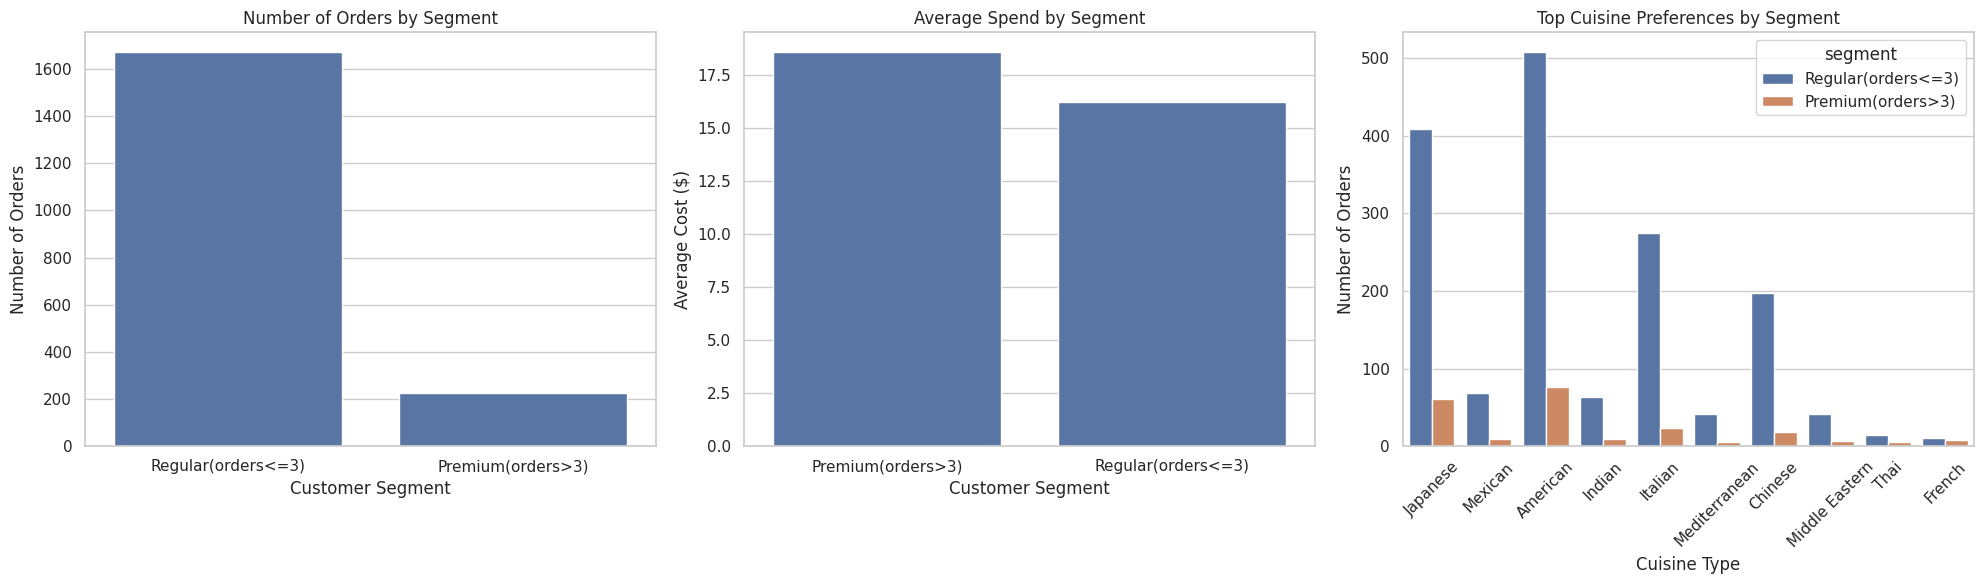

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# 1. Number of orders by segment
sns.countplot(x='segment', data=df, ax=axes[0])
axes[0].set_title("Number of Orders by Segment")
axes[0].set_ylabel("Number of Orders")
axes[0].set_xlabel("Customer Segment")

# 2. Average spend by segment
avg_spend = df.groupby('segment')['cost'].mean().reset_index()
sns.barplot(x='segment', y='cost', data=avg_spend, ax=axes[1])
axes[1].set_title("Average Spend by Segment")
axes[1].set_ylabel("Average Cost ($)")
axes[1].set_xlabel("Customer Segment")

# 3. Cuisine preferences by segment
# Take top 10 cuisines for clarity
top_cuisines = df['cuisine_type'].value_counts().nlargest(10).index
df_top_cuisines = df[df['cuisine_type'].isin(top_cuisines)]
sns.countplot(x='cuisine_type', hue='segment', data=df_top_cuisines, ax=axes[2])
axes[2].set_title("Top Cuisine Preferences by Segment")
axes[2].set_ylabel("Number of Orders")
axes[2].set_xlabel("Cuisine Type")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#this helps us recommmend more offers/ deals to regular users to get them to order more and make them premium members, thus ultimately they spend more , more average as well. recommend them with more famous cuisines like american, japanese and italian to gain even higher ordersplaced

##**FINAL OUTCOMES :**

#trying to recommend user restaurants based on the cuisines they like

In [107]:
# Pick a sample user
user_id = df['customer_id'].iloc[456]

# User's order history
user_data = df[df['customer_id'] == user_id]

# 1. Top cuisines preferred by the user (ONLY names)
top_cuisines = (
    user_data['cuisine_type']
    .value_counts()
    .head(3)
    .index
)

# 2. Top restaurants ordered by the user (ONLY names)
top_restaurants = (
    user_data['restaurant']
    .value_counts()
    .head(3)
    .index
)

# 3. Recommend restaurants from preferred cuisines (keep counts here)
recommended_restaurants = (
    df[
        (df['cuisine_type'].isin(top_cuisines)) &
        (~df['restaurant'].isin(top_restaurants))
    ]['restaurant']
    .value_counts()
    .head(5)
)
print("for user :",user_id)
print("Top cuisines of user orders:", list(top_cuisines), "\n")
print("Top restaurants of user orders:", list(top_restaurants), "\n")
print("Based on your taste, we Recommended restaurants (with order counts):")
print(recommended_restaurants)


for user : 53289
Top cuisines of user orders: ['Japanese'] 

Top restaurants of user orders: ['The Loop'] 

Based on your taste, we Recommended restaurants (with order counts):
restaurant
Blue Ribbon Sushi                119
TAO                               49
Blue Ribbon Sushi Bar & Grill     44
Nobu Next Door                    42
Sushi of Gari 46                  37
Name: count, dtype: int64


### MACHINE LEARNING :::

In [108]:
###trying to apply decision tree to find if delivery is delayed or not for an order##########

##  Load the dataset


In [110]:
import pandas as pd

df = pd.read_csv("foodhub_order.csv")

# Target: late delivery (data-driven threshold for this dataset)
df["late_delivery"] = (df["delivery_time"] > 30).astype(int)

print("Total orders:", len(df))
print(df["late_delivery"].value_counts())
print(df["late_delivery"].value_counts(normalize=True))


Total orders: 1898
late_delivery
0    1749
1     149
Name: count, dtype: int64
late_delivery
0    0.921496
1    0.078504
Name: proportion, dtype: float64


# DO NOT include delivery_time in features (it's used to create the label)


In [111]:
features = [
    "cost_of_the_order",
    "food_preparation_time",
    "day_of_the_week",
    "cuisine_type",
    "restaurant_name",
]

X = df[features].copy()
y = df["late_delivery"].copy()

# Basic missing value handling
X["day_of_the_week"] = X["day_of_the_week"].fillna("Unknown")
X["cuisine_type"] = X["cuisine_type"].fillna("Unknown")
X["restaurant_name"] = X["restaurant_name"].fillna("Unknown")

# If numeric columns have missing, fill with median
for col in ["cost_of_the_order", "food_preparation_time"]:
    X[col] = X[col].fillna(X[col].median())


In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train late rate:", y_train.mean())
print("Test late rate:", y_test.mean())


Train late rate: 0.07839262187088274
Test late rate: 0.07894736842105263


In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

cat_cols = ["day_of_the_week", "cuisine_type", "restaurant_name"]
num_cols = ["cost_of_the_order", "food_preparation_time"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

model = DecisionTreeClassifier(
    max_depth=6,              # keeps tree understandable, avoids overfitting
    min_samples_leaf=20,      # stable splits
    class_weight="balanced",  # because late orders are ~8%
    random_state=42
)

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("dt", model)
])

clf.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['day_of_the_week',
                                                   'cuisine_type',
                                                   'restaurant_name']),
                                                 ('num', 'passthrough',
                                                  ['cost_of_the_order',
                                                   'food_preparation_time'])])),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=20,
                                        random_state=42))])

In [115]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # probability of late

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_prob))


Confusion Matrix:
 [[279  71]
 [  0  30]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89       350
           1       0.30      1.00      0.46        30

    accuracy                           0.81       380
   macro avg       0.65      0.90      0.67       380
weighted avg       0.94      0.81      0.85       380

ROC-AUC: 0.9052380952380952
PR-AUC (Average Precision): 0.31215563539106883


In [116]:
import numpy as np

# Get feature names after one-hot encoding
ohe = clf.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([cat_feature_names, np.array(num_cols)])

importances = clf.named_steps["dt"].feature_importances_
imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print("Top 15 Important Features:")
print(imp.head(15))


Top 15 Important Features:
day_of_the_week_Weekday              0.961392
cost_of_the_order                    0.015530
food_preparation_time                0.010721
cuisine_type_Chinese                 0.004089
cuisine_type_Italian                 0.004028
cuisine_type_American                0.003606
restaurant_name_The Meatball Shop    0.000635
day_of_the_week_Weekend              0.000000
cuisine_type_Korean                  0.000000
cuisine_type_Mediterranean           0.000000
cuisine_type_Mexican                 0.000000
cuisine_type_Middle Eastern          0.000000
cuisine_type_Southern                0.000000
cuisine_type_Spanish                 0.000000
cuisine_type_Thai                    0.000000
dtype: float64


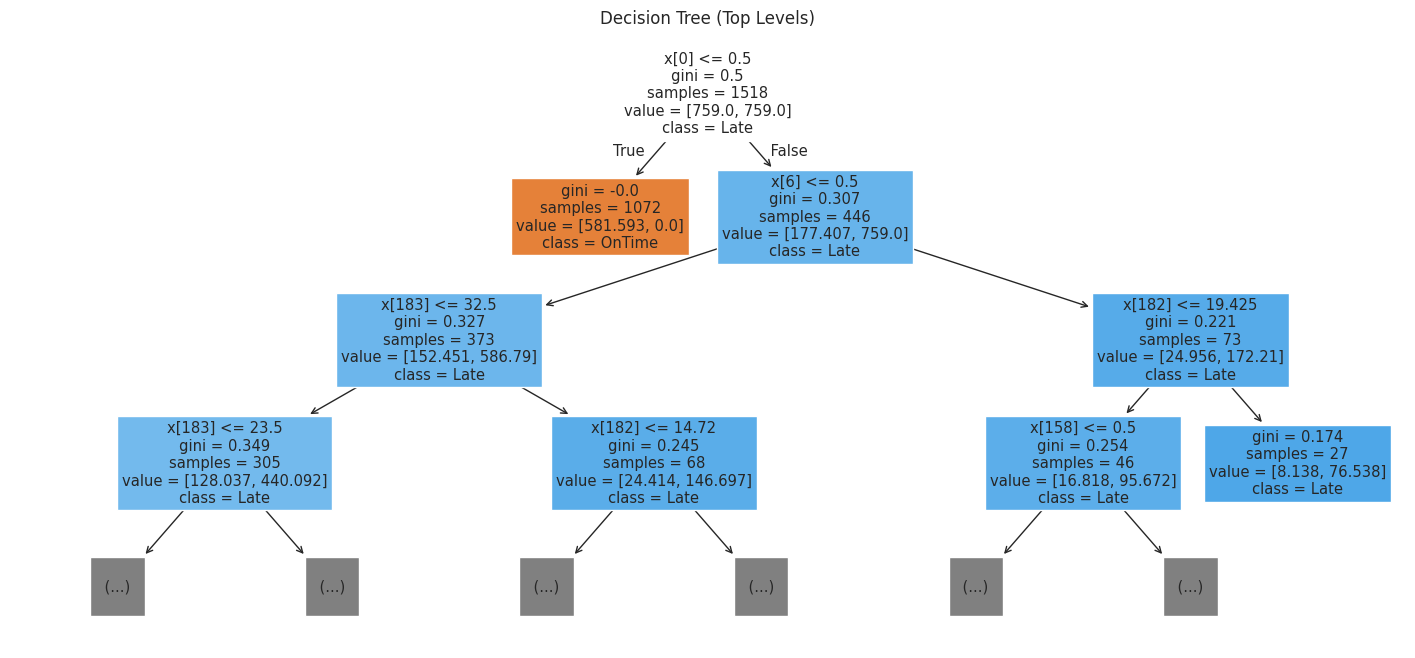

In [118]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(18, 8))
tree.plot_tree(
    clf.named_steps["dt"],
    filled=True,
    max_depth=3,  # show only top levels (readable)
    feature_names=None,  # one-hot has many names; keeping it clean
    class_names=["OnTime", "Late"]
)
plt.title("Decision Tree (Top Levels)")
plt.show()


###predicting on a sample ex

In [71]:
import pandas as pd

new_order = pd.DataFrame([{
    "cost_of_the_order": 256,
    "food_preparation_time": 454,
    "day_of_the_week": "Weekend",
    "cuisine_type": "American",
    "restaurant_name": "The Meatball Shop"
}])

pred = clf.predict(new_order)[0]
prob = clf.predict_proba(new_order)[0][1]

print("Predicted late (0=No, 1=Yes):", pred)
print("Late delivery risk:", prob)


Predicted late (0=No, 1=Yes): 0
Late delivery risk: 0.0


In [122]:
new_order = pd.DataFrame([{
    "cost_of_the_order": 12,
    "food_preparation_time": 23,
    "day_of_the_week": "Weekday",
    "cuisine_type": "Mediterranean",
    "restaurant_name": "Jack's Wife Freda"
}])

print(clf.predict(new_order)[0])
print(clf.predict_proba(new_order)[0][1])

1
0.7231842853450502


###trying to apply randomforest

In [75]:
from sklearn.ensemble import RandomForestClassifier


In [76]:
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=6,             # similar depth as your decision tree
    min_samples_leaf=20,     # stable leaves
    class_weight="balanced", # handle ~8% late orders
    random_state=42,
    n_jobs=-1                # use all CPU cores
)


In [77]:
rf_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", rf_model)
])


In [78]:
rf_clf.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['day_of_the_week',
                                                   'cuisine_type',
                                                   'restaurant_name']),
                                                 ('num', 'passthrough',
                                                  ['cost_of_the_order',
                                                   'food_preparation_time'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=20, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [79]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))


Confusion Matrix:
 [[279  71]
 [  0  30]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89       350
           1       0.30      1.00      0.46        30

    accuracy                           0.81       380
   macro avg       0.65      0.90      0.67       380
weighted avg       0.94      0.81      0.85       380

ROC-AUC: 0.8829047619047619
PR-AUC: 0.2780053294922067


#boosting method :

In [123]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("gb", gb_model)
])

gb_clf.fit(X_train, y_train)

y_pred_gb = gb_clf.predict(X_test)
y_prob_gb = gb_clf.predict_proba(X_test)[:, 1]

print("BOOSTING (Gradient Boosting)")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("PR-AUC:", average_precision_score(y_test, y_prob_gb))


BOOSTING (Gradient Boosting)
Confusion Matrix:
 [[343   7]
 [ 29   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       350
           1       0.12      0.03      0.05        30

    accuracy                           0.91       380
   macro avg       0.52      0.51      0.50       380
weighted avg       0.86      0.91      0.88       380

ROC-AUC: 0.9046190476190475
PR-AUC: 0.29321610108449286


📊 Model Performance Comparison

**Decision Tree**

Recall (Late): 1.00

Precision (Late): 0.30

ROC-AUC: 0.905

PR-AUC: 0.312

**Random Forest**

Recall (Late): 1.00

Precision (Late): 0.30

ROC-AUC: 0.883

PR-AUC: 0.278

**Gradient Boosting**

Recall (Late): 0.03

Precision (Late): 0.12

ROC-AUC: 0.905

PR-AUC: 0.293

##final comparision:

“We compared Decision Tree, Random Forest, and Gradient Boosting models. Although Gradient Boosting achieved high accuracy, it failed to detect late orders due to class imbalance. The Decision Tree achieved perfect recall for late deliveries and the highest PR-AUC, making it the most suitable model for this use case.”